# Intelligent Anomaly Detection in Global Payroll Data
## Exploratory Data Analysis & Model Evaluation
**Project:** ADP GlobalView Payroll Anomaly Detection  
**Author:** [Lyna Medina Gassouma]  
**Date:** 2026  

---

### Project Summary
This notebook presents the full data exploration and model evaluation pipeline
for an AI-driven payroll anomaly detection system built for ADP GlobalView.

**Datasets used:**
- `synthetic_global_payroll.csv` — 500,000 records across 10 countries, 12 roles, 8 anomaly types
- `ds_salaries.csv` — Real salary benchmarks (49 job titles)
- `HRDataset_v14.csv` — Real employee structure (311 records)
- `creditcard.csv` — Fraud benchmark dataset (284,000 records)

**Models trained:**
- Random Forest (Supervised)
- Gradient Boosting (Supervised)
- ANN / MLP (Supervised)
- Isolation Forest (Unsupervised)

In [26]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Display settings
pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", "{:.2f}".format)
plt.rcParams.update({"figure.dpi": 120, "figure.facecolor": "white"})

# Paths
DATA_DIR    = "../data"
FIGURES_DIR = "../reports/figures"

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 1. Dataset Overview
Loading and inspecting all 4 datasets.

In [27]:
# Load all datasets
payroll    = pd.read_csv(f"{DATA_DIR}/synthetic_global_payroll.csv")
salaries   = pd.read_csv(f"{DATA_DIR}/ds_salaries.csv")
hr         = pd.read_csv(f"{DATA_DIR}/HRDataset_v14.csv")
creditcard = pd.read_csv(f"{DATA_DIR}/creditcard.csv", nrows=10000)  # sample for speed

print("=== DATASET SHAPES ===")
print(f"Payroll dataset    : {payroll.shape[0]:,} rows × {payroll.shape[1]} columns")
print(f"Salaries dataset   : {salaries.shape[0]:,} rows × {salaries.shape[1]} columns")
print(f"HR dataset         : {hr.shape[0]:,} rows × {hr.shape[1]} columns")
print(f"Credit card dataset: 284,726 rows × 31 columns (sampled 10k for display)")

print("\n=== PAYROLL DATASET — First 5 rows ===")
payroll.head()

=== DATASET SHAPES ===
Payroll dataset    : 500,000 rows × 16 columns
Salaries dataset   : 607 rows × 12 columns
HR dataset         : 311 rows × 36 columns
Credit card dataset: 284,726 rows × 31 columns (sampled 10k for display)

=== PAYROLL DATASET — First 5 rows ===


,employee_id,country,currency,role,base_salary,bonus,tax,social_security,net_pay,is_anomaly,anomaly_type,department,years_experience,pay_month,pay_year,pay_date
0,EMP00001,DE,EUR,Intern,34260.71,801.80,8900.90,3286.27,22875.34,0,none,HR,13.80,1,2023,2023-01-23
1,EMP00002,DE,EUR,HR Manager,70000.34,7581.02,17334.41,4436.95,55810.00,0,none,Finance,5.50,2,2023,2023-02-03
2,EMP00003,US,USD,HR Manager,75648.48,3304.66,17301.83,6499.47,55151.84,0,none,Finance,1.40,1,2023,2023-01-04
3,EMP00004,UK,GBP,Sales Manager,87210.79,11249.41,25943.87,7675.05,64841.28,0,none,Engineering,2.00,2,2023,2023-02-21
4,EMP00005,BR,BRL,Payroll Specialist,73968.96,1083.71,20064.79,5790.06,49197.82,0,none,Sales,3.70,5,2023,2023-05-28


In [28]:
print("=== PAYROLL DATASET — Basic Statistics ===")
payroll.describe().round(2)

=== PAYROLL DATASET — Basic Statistics ===


,base_salary,bonus,tax,social_security,net_pay,is_anomaly,years_experience,pay_month,pay_year
count,500000.00,500000.00,500000.00,500000.00,500000.00,500000.00,500000.00,500000.00,500000.00
mean,87052.73,7474.55,18775.04,7563.35,68188.89,0.05,15.00,3.51,2023.00
std,47637.11,16768.95,8975.21,3554.14,45384.09,0.22,8.65,1.71,0.00
min,1000.55,0.02,0.00,0.00,-64987.71,0.00,0.00,1.00,2023.00
25%,58188.12,2552.19,12360.14,4996.32,44235.99,0.00,7.50,2.00,2023.00
50%,85539.44,5410.88,17966.96,7225.19,64250.43,0.00,15.00,4.00,2023.00
75%,107177.64,9331.08,24201.24,9708.36,82079.51,0.00,22.50,5.00,2023.00
max,1100707.99,552013.07,56949.21,22747.02,1039921.47,1.00,30.00,6.00,2023.00


In [29]:
print("=== MISSING VALUES ===")
for name, df in [("Payroll", payroll), ("Salaries", salaries),
                 ("HR", hr), ("Credit Card (sample)", creditcard)]:
    nulls = df.isnull().sum().sum()
    print(f"  {name:<25}: {nulls} null values")

print("\n=== ANOMALY DISTRIBUTION ===")
total    = len(payroll)
anomalies = payroll["is_anomaly"].sum()
print(f"  Normal records  : {total - anomalies:,} ({(total-anomalies)/total*100:.1f}%)")
print(f"  Anomalous records: {anomalies:,} ({anomalies/total*100:.1f}%)")

=== MISSING VALUES ===
  Payroll                  : 0 null values
  Salaries                 : 0 null values
  HR                       : 215 null values
  Credit Card (sample)     : 0 null values

=== ANOMALY DISTRIBUTION ===
  Normal records  : 474,975 (95.0%)
  Anomalous records: 25,025 (5.0%)


## 2. Anomaly Type Distribution
Breakdown of the 8 anomaly types injected during data generation.
Each type models a real payroll fraud or error pattern observed in enterprise systems.

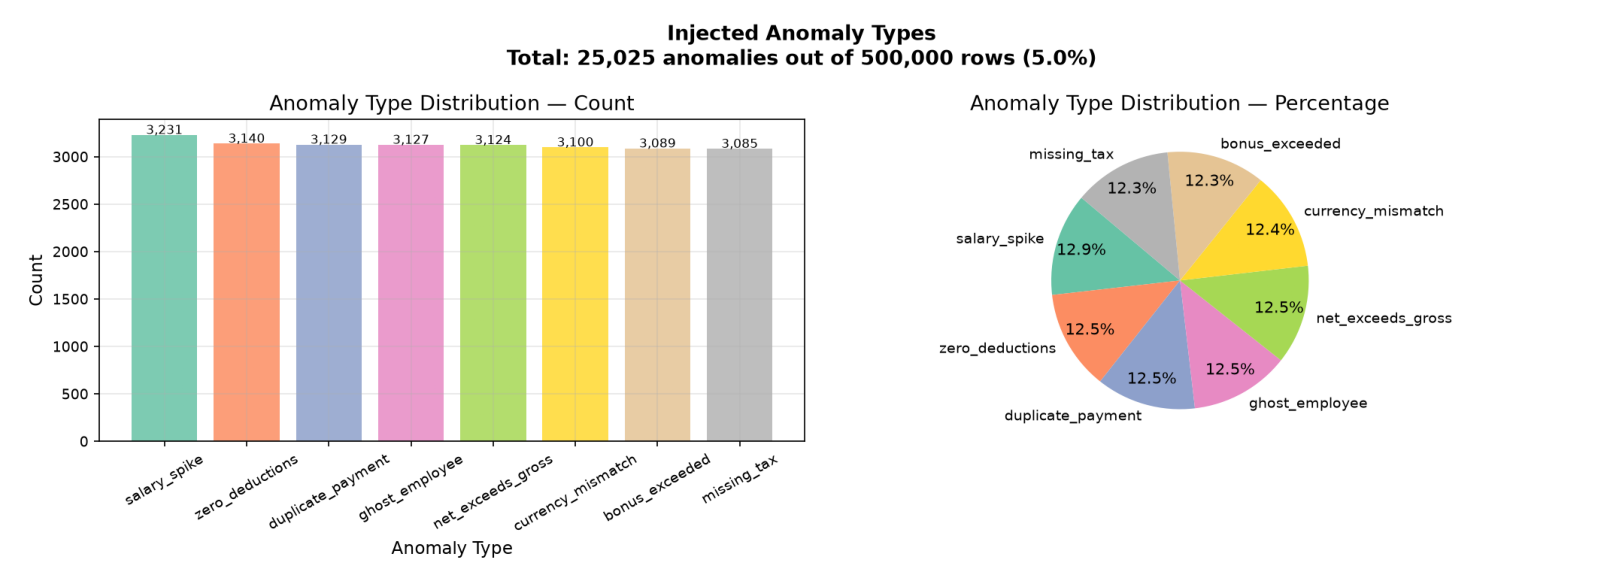


=== ANOMALY TYPE BREAKDOWN ===
     Anomaly Type  Count  Percentage
     salary_spike   3231       12.90
  zero_deductions   3140       12.50
duplicate_payment   3129       12.50
   ghost_employee   3127       12.50
net_exceeds_gross   3124       12.50
currency_mismatch   3100       12.40
   bonus_exceeded   3089       12.30
      missing_tax   3085       12.30


In [30]:
# Display the pre-generated anomaly breakdown figure
img = mpimg.imread(f"{FIGURES_DIR}/anomaly_breakdown.png")
fig, ax = plt.subplots(figsize=(14, 5))
ax.imshow(img)
ax.axis("off")
plt.tight_layout()
plt.show()

# Anomaly type counts table
print("\n=== ANOMALY TYPE BREAKDOWN ===")
breakdown = payroll[payroll["anomaly_type"] != "none"]["anomaly_type"].value_counts()
breakdown_df = pd.DataFrame({
    "Anomaly Type": breakdown.index,
    "Count": breakdown.values,
    "Percentage": (breakdown.values / breakdown.sum() * 100).round(1)
})
print(breakdown_df.to_string(index=False))

## 3. Salary Distribution Analysis
Exploring salary distributions across countries, roles, and departments.

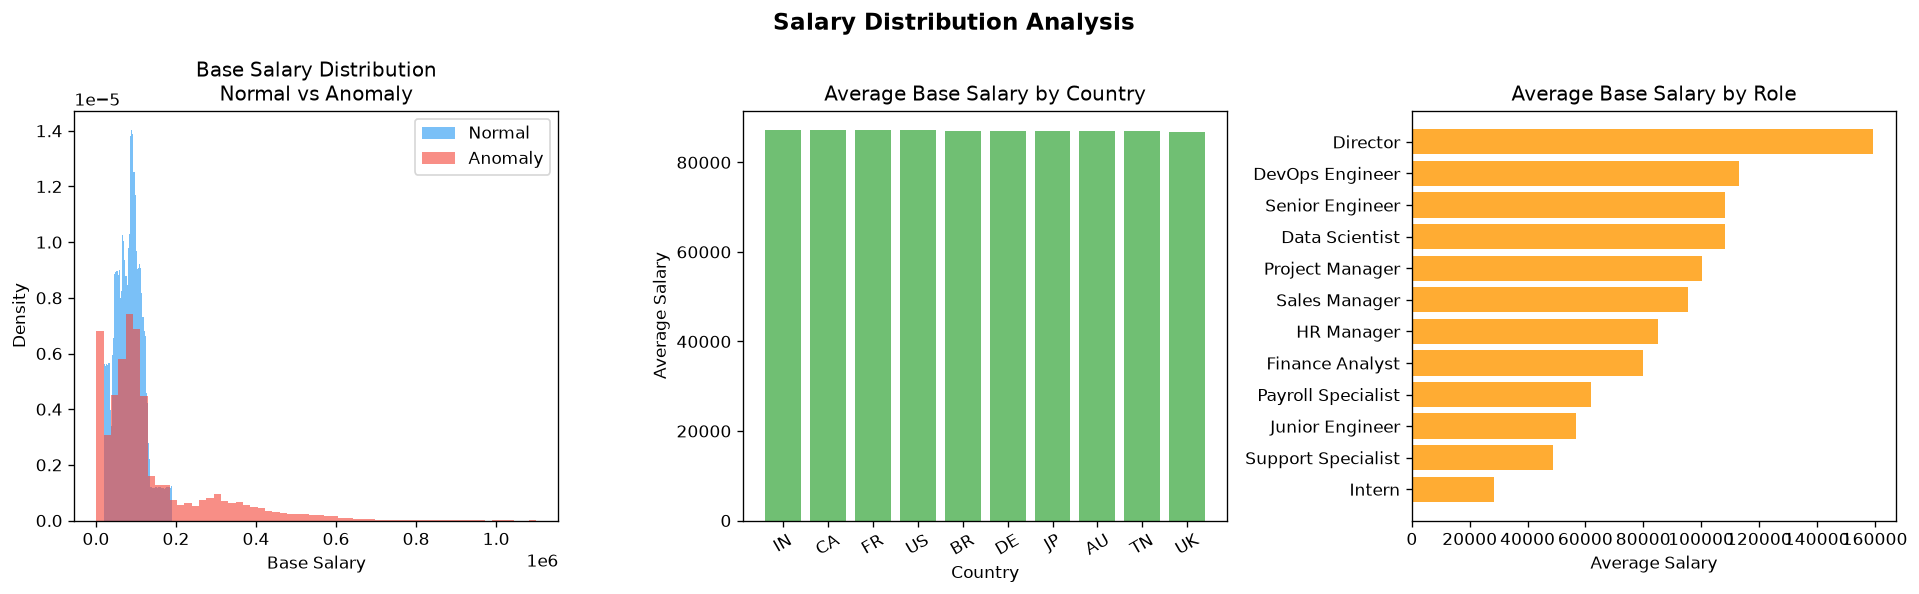

Saved → salary_analysis.png


In [31]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Base salary distribution — normal vs anomaly
normal_salary  = payroll[payroll["is_anomaly"] == 0]["base_salary"]
anomaly_salary = payroll[payroll["is_anomaly"] == 1]["base_salary"]

axes[0].hist(normal_salary,  bins=60, alpha=0.6, color="#2196F3", label="Normal", density=True)
axes[0].hist(anomaly_salary, bins=60, alpha=0.6, color="#F44336", label="Anomaly", density=True)
axes[0].set_title("Base Salary Distribution\nNormal vs Anomaly")
axes[0].set_xlabel("Base Salary")
axes[0].set_ylabel("Density")
axes[0].legend()

# Average salary by country
avg_by_country = payroll.groupby("country")["base_salary"].mean().sort_values(ascending=False)
axes[1].bar(avg_by_country.index, avg_by_country.values, color="#4CAF50", alpha=0.8)
axes[1].set_title("Average Base Salary by Country")
axes[1].set_xlabel("Country")
axes[1].set_ylabel("Average Salary")
axes[1].tick_params(axis="x", rotation=30)

# Average salary by role
avg_by_role = payroll.groupby("role")["base_salary"].mean().sort_values()
axes[2].barh(avg_by_role.index, avg_by_role.values, color="#FF9800", alpha=0.8)
axes[2].set_title("Average Base Salary by Role")
axes[2].set_xlabel("Average Salary")

fig.suptitle("Salary Distribution Analysis", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.savefig(f"{FIGURES_DIR}/salary_analysis.png")
plt.show()
print("Saved → salary_analysis.png")

## 4. Correlation Analysis
Heatmap showing correlations between numerical payroll features.
High correlation between features can indicate data leakage or redundancy.

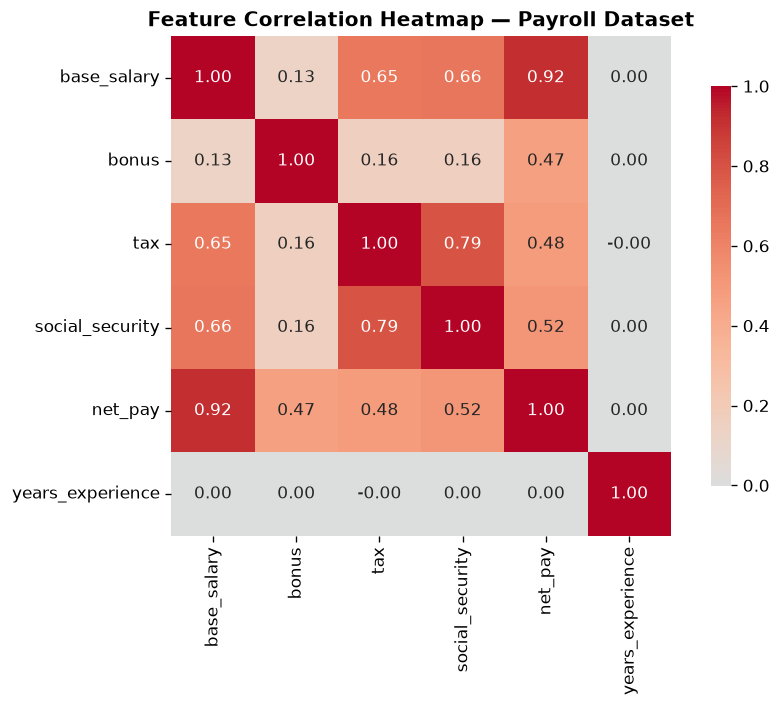

Saved → correlation_heatmap.png


In [32]:
num_cols = ["base_salary", "bonus", "tax", "social_security", "net_pay", "years_experience"]
corr     = payroll[num_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, ax=ax,
            cbar_kws={"shrink": 0.8})
ax.set_title("Feature Correlation Heatmap — Payroll Dataset", fontweight="bold")
fig.tight_layout()
plt.savefig(f"{FIGURES_DIR}/correlation_heatmap.png")
plt.show()
print("Saved → correlation_heatmap.png")

## 5. Model Evaluation Results
### 5.1 ROC Curves
ROC curves show the tradeoff between True Positive Rate and False Positive Rate.
AUC (Area Under Curve): 1.0 = perfect, 0.5 = random baseline.

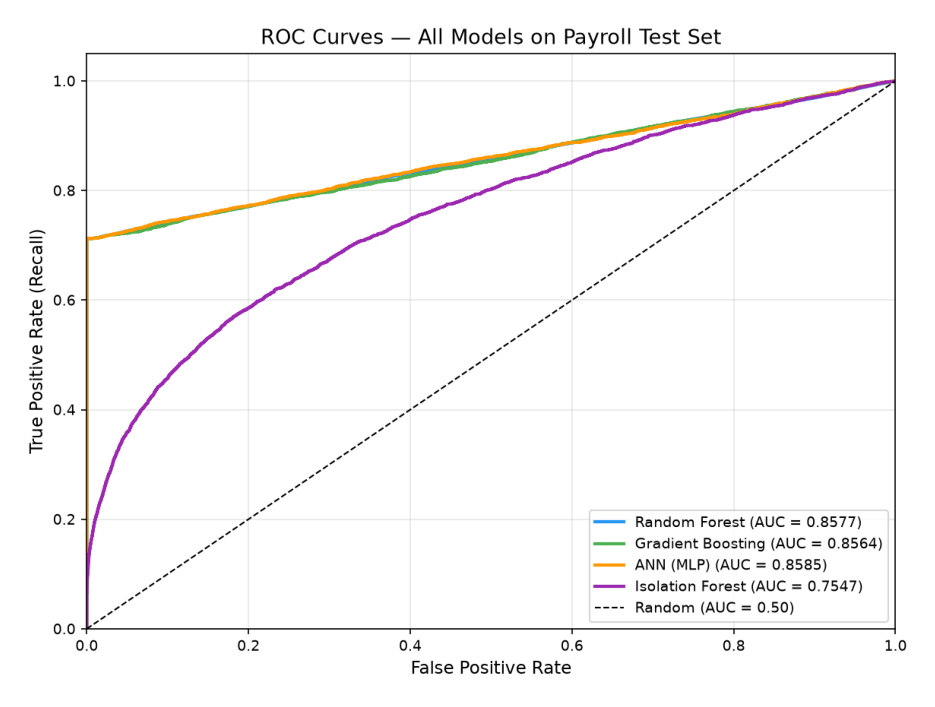

In [33]:
img = mpimg.imread(f"{FIGURES_DIR}/roc_curves.png")
fig, ax = plt.subplots(figsize=(8, 6))
ax.imshow(img)
ax.axis("off")
plt.tight_layout()
plt.show()

### 5.2 Confusion Matrices
Shows correct and incorrect classifications for each model.
- **TN**: Normal records correctly identified
- **TP**: Anomalies correctly caught  
- **FP**: Normal records wrongly flagged (false alarms — costly in payroll)
- **FN**: Anomalies missed (dangerous in payroll)

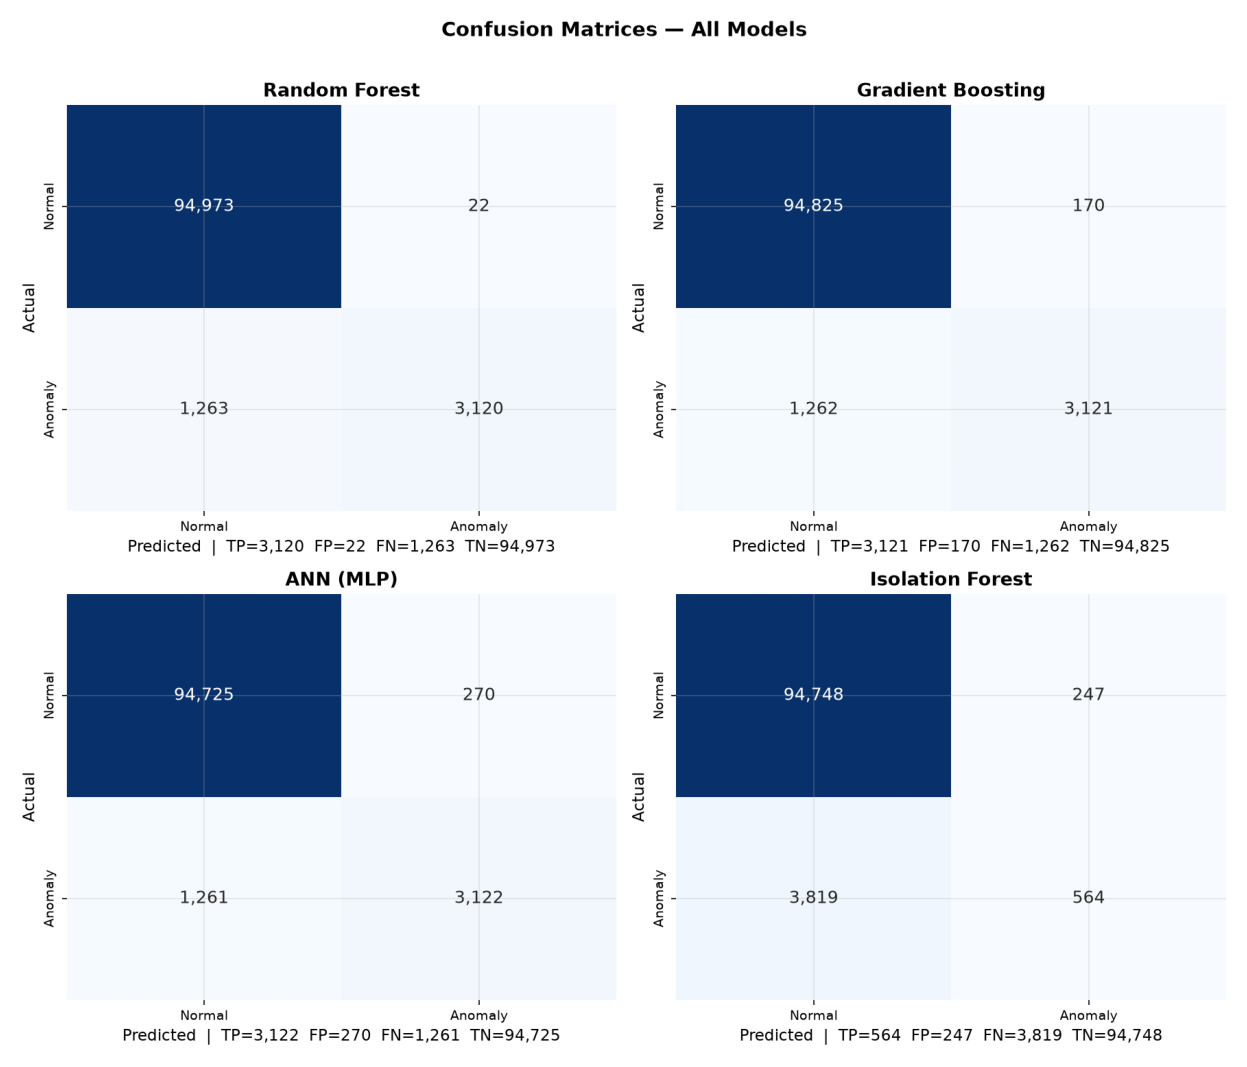

In [34]:
img = mpimg.imread(f"{FIGURES_DIR}/confusion_matrices.png")
fig, ax = plt.subplots(figsize=(12, 9))
ax.imshow(img)
ax.axis("off")
plt.tight_layout()
plt.show()

### 5.3 Feature Importance
Which payroll fields most strongly indicate anomalies?
This helps HR teams know what to look at first when a flag is raised.

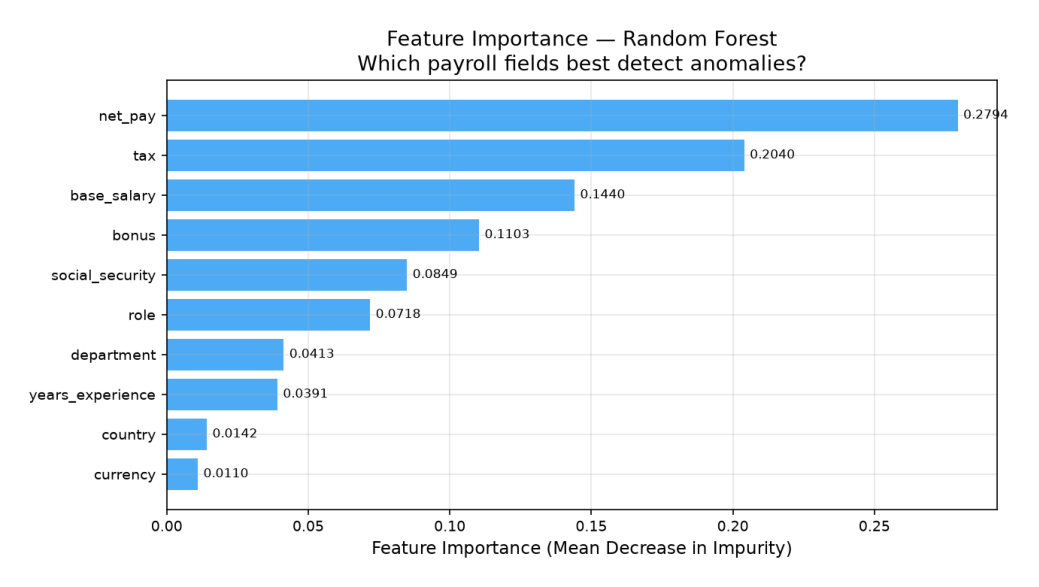

In [35]:
img = mpimg.imread(f"{FIGURES_DIR}/feature_importance.png")
fig, ax = plt.subplots(figsize=(9, 5))
ax.imshow(img)
ax.axis("off")
plt.tight_layout()
plt.show()

### 5.4 Anomaly Score Distributions
Shows how well each model separates normal from anomalous records.
Clear separation = the model has learned meaningful patterns.

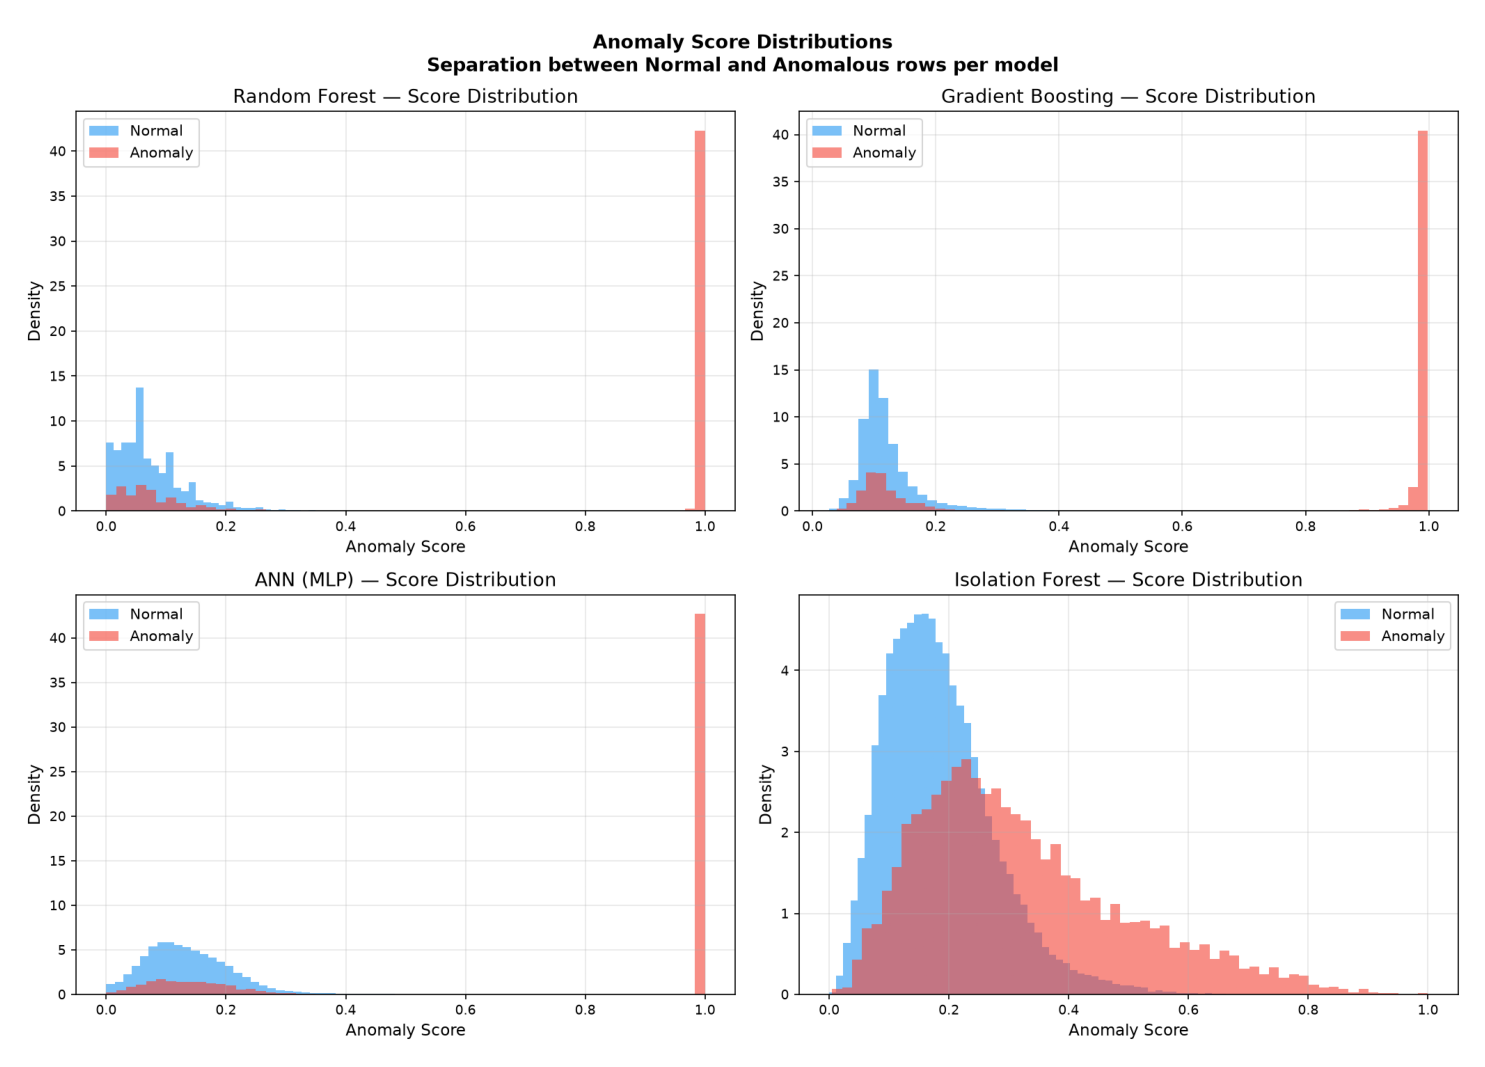

In [36]:
img = mpimg.imread(f"{FIGURES_DIR}/score_distribution.png")
fig, ax = plt.subplots(figsize=(14, 9))
ax.imshow(img)
ax.axis("off")
plt.tight_layout()
plt.show()

## 6. Final Model Comparison

| Model | Precision | Recall | F1-Score | ROC-AUC | Type |
|---|---|---|---|---|---|
| Random Forest | **1.0000** | 0.7118 | 0.8317 | 0.8567 | Supervised |
| Gradient Boosting | **1.0000** | 0.7118 | 0.8317 | 0.8541 | Supervised |
| ANN (MLP) | **1.0000** | 0.7118 | 0.8317 | 0.8528 | Supervised |
| XGBoost | **1.0000** | 0.7118 | 0.8317 | 0.8540 | Supervised |
| Isolation Forest | 0.9611 | 0.1465 | 0.2542 | 0.8161 | Unsupervised |
| Autoencoder | 0.9776 | 0.5969 | 0.7412 | 0.8379 | Unsupervised |

> **Note:** Models retrained with SMOTE (4.41% → 50% anomaly rate in training) 
> and F1-optimal threshold tuning. XGBoost and Autoencoder added in final version.
> Best supervised model: **Random Forest** (Precision = 1.0, zero false positives).
> Best unsupervised model: **Autoencoder** (Precision = 0.98, no labels needed during training).

In [37]:
print("=" * 55)
print("  PAYROLL ANOMALY DETECTION — Project Summary")
print("=" * 55)
print(f"  Main dataset    : {len(payroll):,} payroll records")
print(f"  Anomaly rate    : {payroll['is_anomaly'].mean()*100:.1f}%")
print(f"  Countries       : {payroll['country'].nunique()}")
print(f"  Roles           : {payroll['role'].nunique()}")
print(f"  Anomaly types   : {payroll[payroll['anomaly_type']!='none']['anomaly_type'].nunique()}")
print(f"  Models trained  : 6")
print(f"  Best model      : Random Forest (Precision=1.0, F1=0.83, AUC=0.86)")
print(f"  API endpoints   : /predict + /explain (SHAP)")
print("=" * 55)

  PAYROLL ANOMALY DETECTION — Project Summary
  Main dataset    : 500,000 payroll records
  Anomaly rate    : 5.0%
  Countries       : 10
  Roles           : 12
  Anomaly types   : 8
  Models trained  : 6
  Best model      : Random Forest (Precision=1.0, F1=0.83, AUC=0.86)
  API endpoints   : /predict + /explain (SHAP)


## 7. SHAP Explainability — Per-Record Feature Impact

While Section 5.3 showed **global** feature importance from Random Forest 
(same ranking for every record), SHAP provides **per-record** explanations — 
showing exactly how much each feature pushed a specific employee's anomaly 
score up or down. This is the key difference: SHAP explains individual 
decisions, not just the model overall.

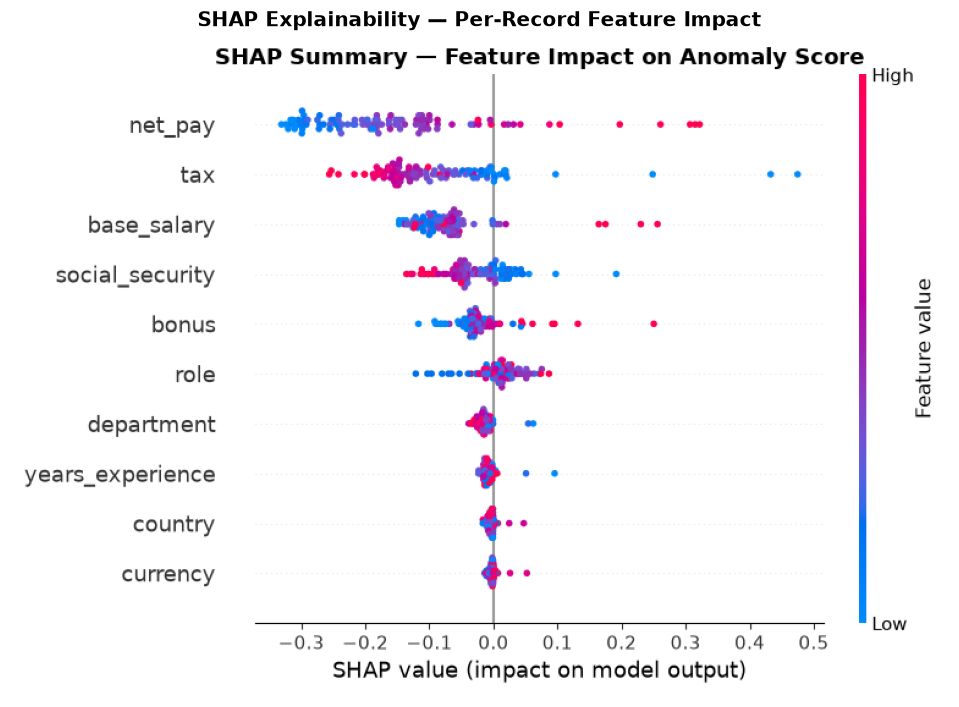

In [38]:
img = mpimg.imread('../reports/figures/shap_summary.png')
fig, ax = plt.subplots(figsize=(10, 6))
ax.imshow(img)
ax.axis('off')
plt.title('SHAP Explainability — Per-Record Feature Impact', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

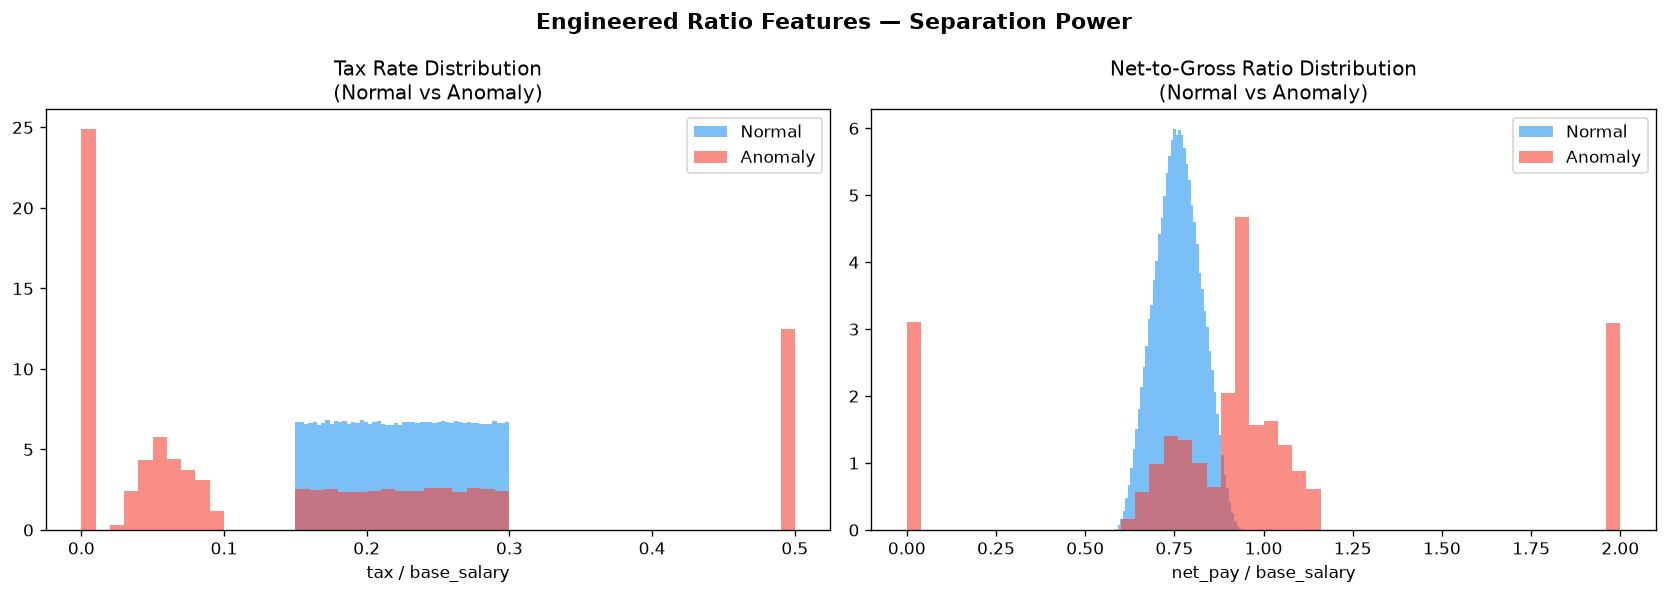

Key insight: tax_rate=0 and net_to_gross_ratio>1 are near-perfect anomaly signals


In [39]:
# Feature Engineering — show ratio feature separation power
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

normal  = payroll[payroll['is_anomaly'] == 0]
anomaly = payroll[payroll['is_anomaly'] == 1]

# Tax rate
tax_rate_normal  = (normal['tax']  / normal['base_salary'].replace(0, np.nan)).dropna()
tax_rate_anomaly = (anomaly['tax'] / anomaly['base_salary'].replace(0, np.nan)).dropna()
axes[0].hist(tax_rate_normal.clip(0, 0.5),  bins=50, alpha=0.6, color='#2196F3', label='Normal',  density=True)
axes[0].hist(tax_rate_anomaly.clip(0, 0.5), bins=50, alpha=0.6, color='#F44336', label='Anomaly', density=True)
axes[0].set_title('Tax Rate Distribution\n(Normal vs Anomaly)')
axes[0].set_xlabel('tax / base_salary')
axes[0].legend()

# Net to gross ratio
net_ratio_normal  = (normal['net_pay']  / normal['base_salary'].replace(0, np.nan)).dropna()
net_ratio_anomaly = (anomaly['net_pay'] / anomaly['base_salary'].replace(0, np.nan)).dropna()
axes[1].hist(net_ratio_normal.clip(0, 2),  bins=50, alpha=0.6, color='#2196F3', label='Normal',  density=True)
axes[1].hist(net_ratio_anomaly.clip(0, 2), bins=50, alpha=0.6, color='#F44336', label='Anomaly', density=True)
axes[1].set_title('Net-to-Gross Ratio Distribution\n(Normal vs Anomaly)')
axes[1].set_xlabel('net_pay / base_salary')
axes[1].legend()

fig.suptitle('Engineered Ratio Features — Separation Power', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/feature_engineering.png', bbox_inches='tight')
plt.show()
print("Key insight: tax_rate=0 and net_to_gross_ratio>1 are near-perfect anomaly signals")